In [13]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

In [9]:
DATA_PATH  = "datos/train.csv"
TARGET_COL = "Will_Buy_EV"
DROP_COLS  = ["id", TARGET_COL]
TEST_SIZE  = 0.2
N_SPLITS   = 5
SEED       = 42

In [10]:
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=DROP_COLS)
y = df[TARGET_COL].map({'No': 0, 'Yes': 1}).values

cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
num = X.select_dtypes(include='number').columns.tolist()
for c in cat:
    X[c] = X[c].astype('category')

CLASSES = np.array(['No', 'Yes'])
N_CLASSES = 2

print("Categóricas:", cat)
print("Numéricas:", num)
print(pd.Series(y).value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

Categóricas: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
Numéricas: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
0    0.825355
1    0.174645
Name: proportion, dtype: float64


In [11]:
def prep_lineal():
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler())
        ]), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat),
    ])

In [14]:
def get_models():
    return {
        "Naive Bayes": Pipeline([
            ("prep", prep_lineal()),
            ("clf",  GaussianNB())
        ]),
        "LinearSVC": Pipeline([
            ("prep", prep_lineal()),
            ("clf",  CalibratedClassifierCV(LinearSVC(C=0.5, random_state=SEED), cv=3))
        ]),
        "Logistic Regression": Pipeline([
            ("prep", prep_lineal()),
            ("clf",  LogisticRegression(C=1.0, max_iter=2000))
        ]),
        "XGBoost": XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            tree_method="hist", enable_categorical=True,
            random_state=SEED, n_jobs=-1),
        "LightGBM": LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=31,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            random_state=SEED, n_jobs=-1, verbose=-1),
    }

MODEL_NAMES = list(get_models().keys())

In [19]:
def evaluar(y_true, proba):
    pred = proba.argmax(1)
    res = {
        "Accuracy":  accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "Recall":    recall_score(y_true, pred, average="macro", zero_division=0),
        "F1 macro":  f1_score(y_true, pred, average="macro"),
    }
    if N_CLASSES == 2:
        res["ROC-AUC"] = roc_auc_score(y_true, proba[:, 1])
    else:
        res["ROC-AUC"] = roc_auc_score(y_true, proba, multi_class="ovr")
    return res

In [15]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof = {m: np.zeros((len(y_train), N_CLASSES)) for m in MODEL_NAMES}

for fold, (tr, va) in enumerate(skf.split(X_train, y_train), 1):
    for name, model in get_models().items():
        model.fit(X_train.iloc[tr], y_train[tr])
        oof[name][va] = model.predict_proba(X_train.iloc[va])
    print(f"Fold {fold}/{N_SPLITS} listo")

for m in MODEL_NAMES:
    print(f"{m:22s} F1 CV: {f1_score(y_train, oof[m].argmax(1), average='macro'):.4f}")

Fold 1/5 listo
Fold 2/5 listo
Fold 3/5 listo
Fold 4/5 listo
Fold 5/5 listo
Naive Bayes            F1 CV: 0.6186
LinearSVC              F1 CV: 0.8112
Logistic Regression    F1 CV: 0.8116
XGBoost                F1 CV: 0.8181
LightGBM               F1 CV: 0.8190


In [16]:
test_proba, tiempos, modelos_finales = {}, {}, {}
for name, model in get_models().items():
    t0 = time.time()
    model.fit(X_train, y_train)
    tiempos[name] = time.time() - t0
    test_proba[name] = model.predict_proba(X_test)
    modelos_finales[name] = model
    print(f"{name:22s} entrenado en {tiempos[name]:.1f}s")

Naive Bayes            entrenado en 3.3s
LinearSVC              entrenado en 18.3s
Logistic Regression    entrenado en 6.7s
XGBoost                entrenado en 31.0s
LightGBM               entrenado en 19.5s


In [17]:
P_oof  = np.stack([oof[m] for m in MODEL_NAMES])         # (modelos, n, clases)
P_test = np.stack([test_proba[m] for m in MODEL_NAMES])

# 1) Voting promedio
vote_test = P_test.mean(0)

# 2) Voting ponderado (pesos optimizados sobre OOF)
def perdida(w):
    w = np.abs(w) / np.abs(w).sum()
    return log_loss(y_train, np.tensordot(w, P_oof, axes=1), labels=range(N_CLASSES))

opt = minimize(perdida, np.ones(len(MODEL_NAMES)) / len(MODEL_NAMES), method="Nelder-Mead")
w_opt = np.abs(opt.x) / np.abs(opt.x).sum()
weighted_test = np.tensordot(w_opt, P_test, axes=1)
print("Pesos:", dict(zip(MODEL_NAMES, w_opt.round(3))))

# 3) Stacking (meta-modelo sobre las probabilidades OOF)
Z_oof  = np.hstack([oof[m] for m in MODEL_NAMES])
Z_test = np.hstack([test_proba[m] for m in MODEL_NAMES])
meta = LogisticRegression(C=1.0, max_iter=2000)
meta.fit(Z_oof, y_train)
stack_test = meta.predict_proba(Z_test)

ENSAMBLES = {
    "Ensamble: Voting promedio": vote_test,
    "Ensamble: Voting ponderado": weighted_test,
    "Ensamble: Stacking": stack_test,
}

Pesos: {'Naive Bayes': np.float64(0.0), 'LinearSVC': np.float64(0.0), 'Logistic Regression': np.float64(0.291), 'XGBoost': np.float64(0.361), 'LightGBM': np.float64(0.348)}


In [20]:
resultados = {}
for m in MODEL_NAMES:
    resultados[m] = {**evaluar(y_test, test_proba[m]),
                     "F1 CV (OOF)": f1_score(y_train, oof[m].argmax(1), average="macro"),
                     "Tiempo (s)": tiempos[m]}
for n, p in ENSAMBLES.items():
    resultados[n] = evaluar(y_test, p)

tabla = pd.DataFrame(resultados).T.sort_values("F1 macro", ascending=False)
tabla.style.format("{:.4f}", na_rep="-").background_gradient(
    cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1 macro", "ROC-AUC"])

,Accuracy,Precision,Recall,F1 macro,ROC-AUC,F1 CV (OOF),Tiempo (s)
Ensamble: Voting promedio,0.8904,0.8046,0.8415,0.8209,0.9374,-,-
LightGBM,0.8983,0.8281,0.8103,0.8188,0.9416,0.8190,19.5155
XGBoost,0.8981,0.8277,0.8101,0.8184,0.9417,0.8181,30.9690
Ensamble: Voting ponderado,0.8979,0.8283,0.8075,0.8173,0.9413,-,-
Ensamble: Stacking,0.8983,0.8296,0.8062,0.8171,0.9379,-,-
Logistic Regression,0.8949,0.8228,0.8018,0.8117,0.9380,0.8116,6.7118
LinearSVC,0.8947,0.8228,0.8007,0.8110,0.9378,0.8112,18.3444
Naive Bayes,0.6587,0.6606,0.7786,0.6191,0.9215,0.6186,3.3374


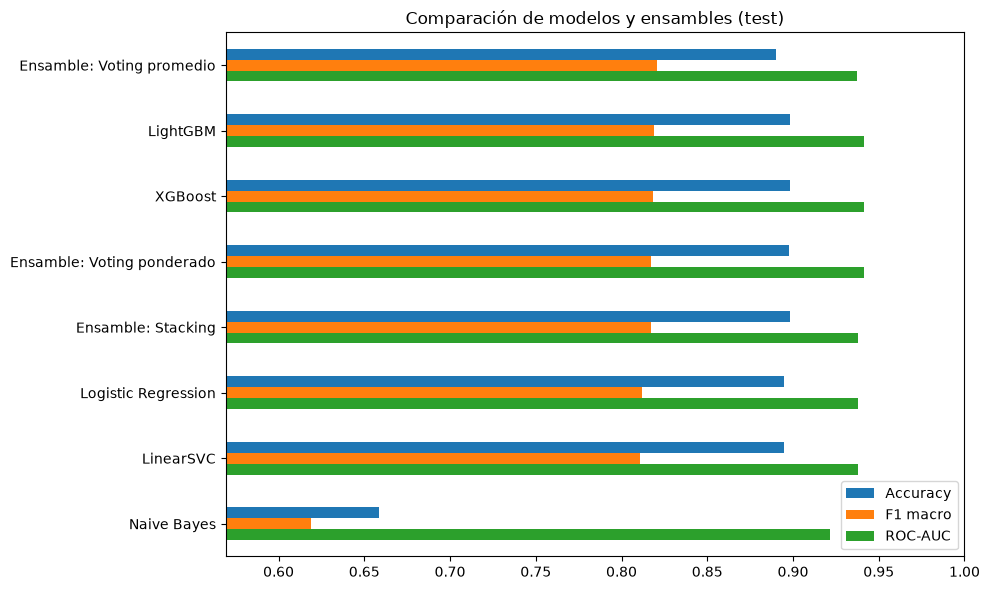

In [21]:
ax = tabla[["Accuracy", "F1 macro", "ROC-AUC"]].plot.barh(figsize=(10, 6))
ax.set_xlim(tabla[["Accuracy", "F1 macro", "ROC-AUC"]].min().min() - 0.05, 1)
ax.set_title("Comparación de modelos y ensambles (test)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

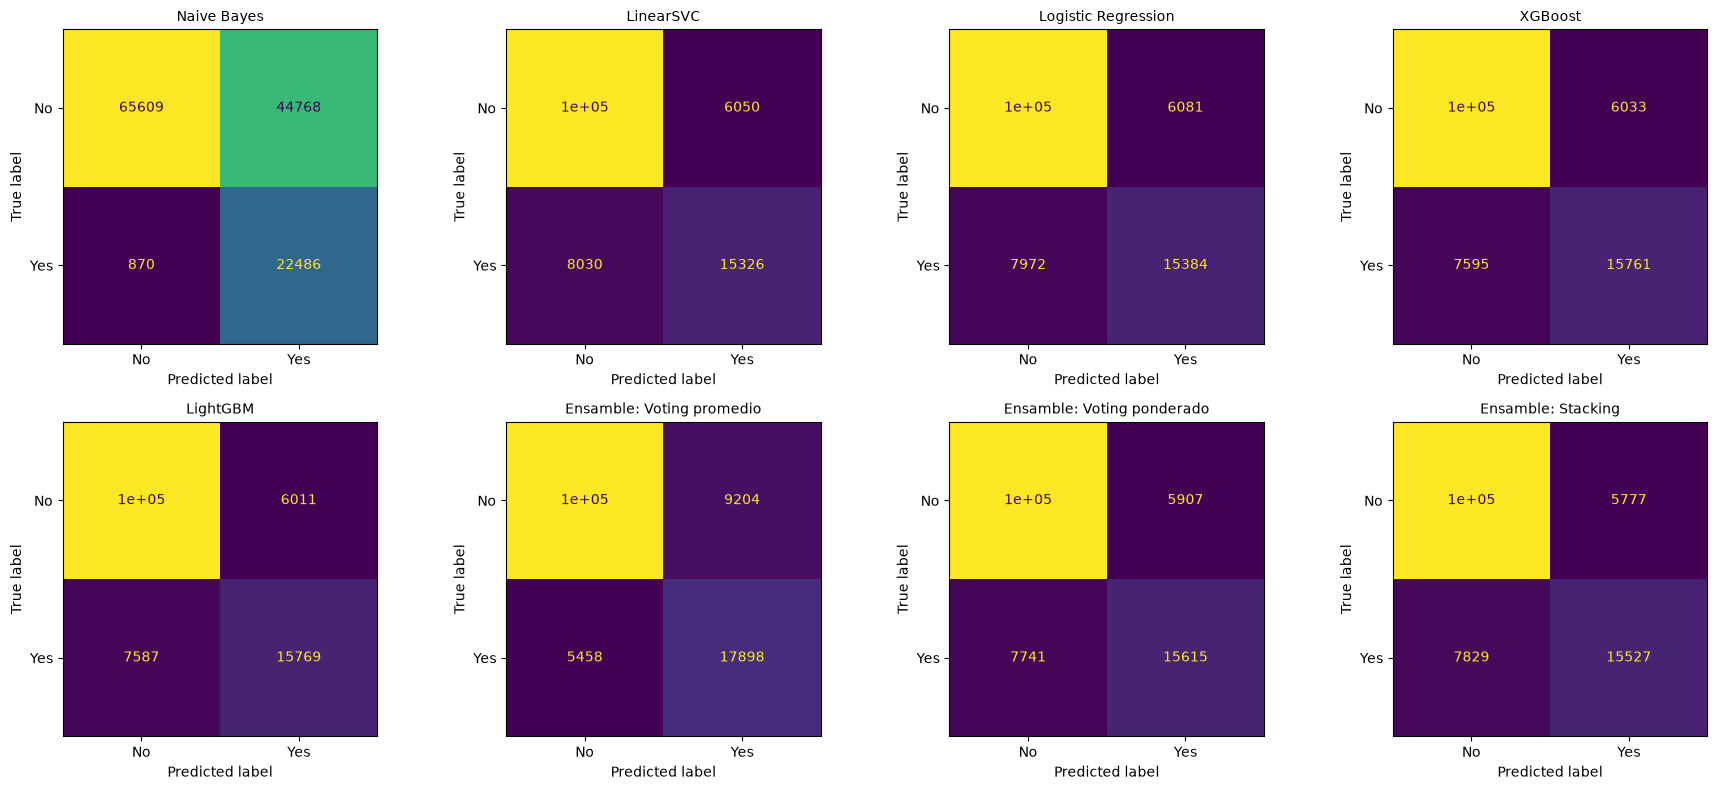

In [22]:
todas = {**test_proba, **ENSAMBLES}
n = len(todas); cols = 4; rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4 * rows))
for ax, (name, p) in zip(axes.flat, todas.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p.argmax(1)),
                           display_labels=CLASSES).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

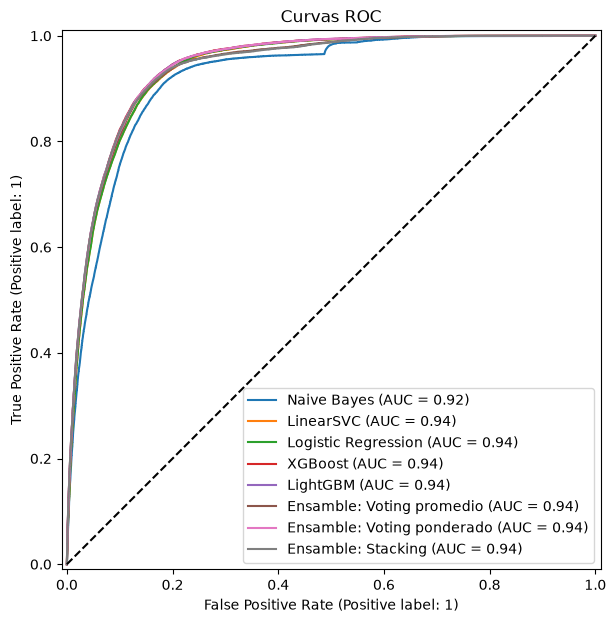

In [23]:
if N_CLASSES == 2:
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, p in todas.items():
        RocCurveDisplay.from_predictions(y_test, p[:, 1], name=name, ax=ax)
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title("Curvas ROC"); plt.show()

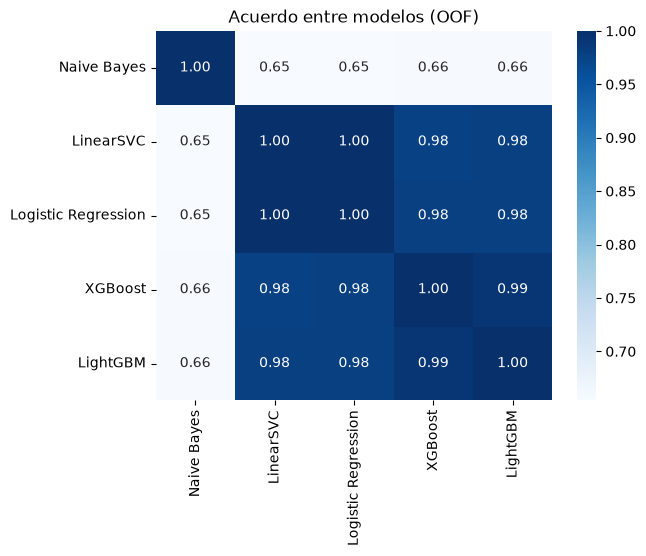

In [24]:
preds = pd.DataFrame({m: oof[m].argmax(1) for m in MODEL_NAMES})
acuerdo = pd.DataFrame(
    [[(preds[a] == preds[b]).mean() for b in MODEL_NAMES] for a in MODEL_NAMES],
    index=MODEL_NAMES, columns=MODEL_NAMES)
sns.heatmap(acuerdo, annot=True, fmt=".2f", cmap="Blues")
plt.title("Acuerdo entre modelos (OOF)"); plt.show()

In [25]:
mejor = tabla.index[0]
print("Mejor modelo:", mejor)
print(classification_report(y_test, todas[mejor].argmax(1), target_names=[str(c) for c in CLASSES]))

Mejor modelo: Ensamble: Voting promedio
              precision    recall  f1-score   support

          No       0.95      0.92      0.93    110377
         Yes       0.66      0.77      0.71     23356

    accuracy                           0.89    133733
   macro avg       0.80      0.84      0.82    133733
weighted avg       0.90      0.89      0.89    133733



In [26]:
MEJOR = tabla.index[0]          # o escríbelo a mano, ej: "LightGBM"
print("Modelo elegido:", MEJOR)

# Reentrenar los modelos base con TODOS los datos (train + test)
# para aprovechar el 100% antes de predecir datos nuevos
REENTRENAR_TODO = True

if REENTRENAR_TODO:
    for name, model in get_models().items():
        model.fit(X, y)
        modelos_finales[name] = model
    print("Modelos reentrenados con todo el dataset")

Modelo elegido: Ensamble: Voting promedio
Modelos reentrenados con todo el dataset


In [27]:
def preparar(df_nuevo):
    Xn = df_nuevo.drop(columns=[c for c in DROP_COLS if c in df_nuevo.columns])
    Xn = Xn[X.columns]  # mismo orden de columnas que en entrenamiento
    for c in cat:
        # mismas categorías que en entrenamiento (si no, XGBoost/LightGBM fallan)
        Xn[c] = pd.Categorical(Xn[c], categories=X[c].cat.categories)
    return Xn

def predecir_proba(Xn, nombre=MEJOR):
    if nombre in MODEL_NAMES:
        return modelos_finales[nombre].predict_proba(Xn)

    P = [modelos_finales[m].predict_proba(Xn) for m in MODEL_NAMES]
    if nombre == "Ensamble: Voting promedio":
        return np.mean(P, axis=0)
    if nombre == "Ensamble: Voting ponderado":
        return np.tensordot(w_opt, np.stack(P), axes=1)
    if nombre == "Ensamble: Stacking":
        return meta.predict_proba(np.hstack(P))
    raise ValueError(f"Modelo no reconocido: {nombre}")



In [29]:
nuevo = pd.read_csv("datos/test.csv")
Xn = preparar(nuevo)

resultado = pd.DataFrame({
    "id": nuevo["id"],
    "Will_Buy_EV": predecir_proba(Xn)[:, 1]   # probabilidad de "Yes"
})
resultado.head()
resultado.to_csv("predicciones/submission.csv", index=False)